In [16]:
# Imports and environment first, all in one place

from dotenv import load_dotenv
from IPython.display import Image, display
from pydantic import BaseModel, Field
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_tool_call
from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from langchain_mcp_adapters.client import MultiServerMCPClient
from langchain_ollama import ChatOllama

load_dotenv(override=True)

llm = ChatOllama(
    model="llama3.2",
    temperature=0,
)

In [4]:
!node --version
!npx --version

v24.14.0
11.9.0


Navigating to https://news.ycombinator.com
Capturing screenshot into playwright_check.png


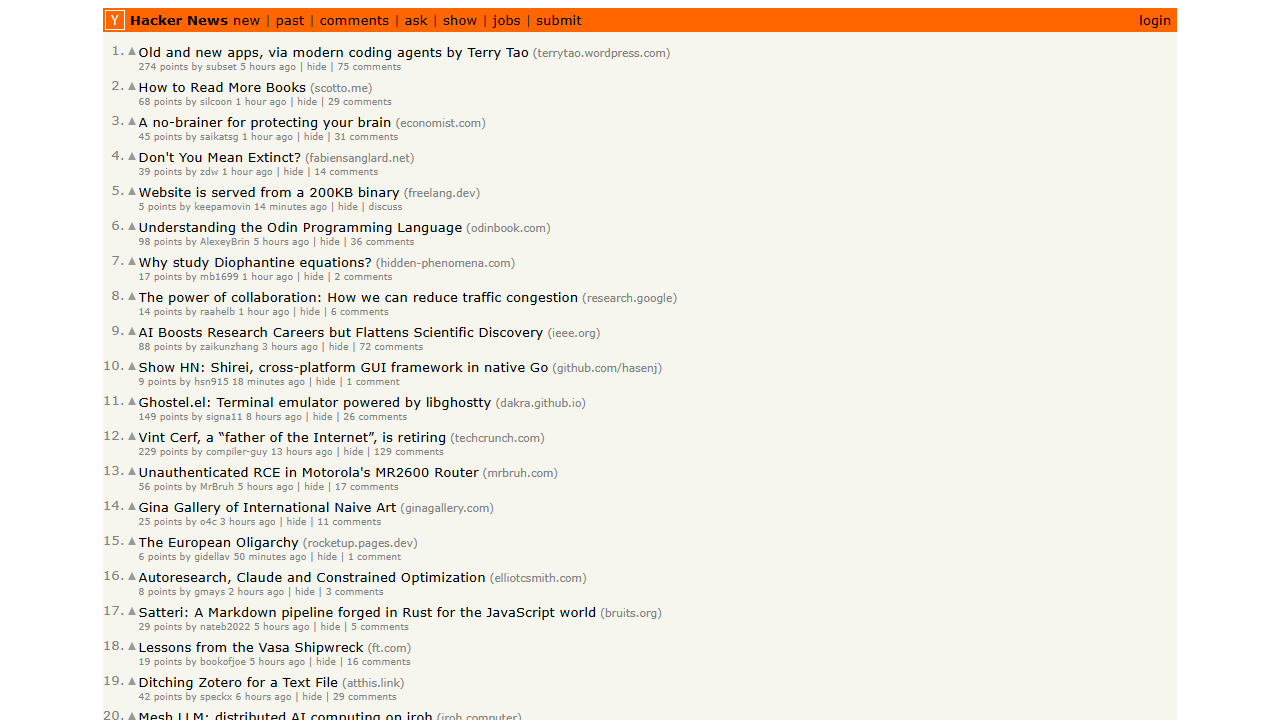

In [5]:
!npx -y playwright@latest screenshot --channel=chrome https://news.ycombinator.com playwright_check.png
display(Image("playwright_check.png"))

In [17]:
import sys

if sys.platform == "win32":
    import subprocess
    from functools import partial
    import langchain_mcp_adapters.sessions as mcp_sessions

    mcp_sessions.stdio_client = partial(mcp_sessions.stdio_client, errlog=subprocess.DEVNULL)
    print("Applied the windows adjustment")

Applied the windows adjustment


In [18]:
client = MultiServerMCPClient({
    "playwright": {
        "transport":"stdio",
        "command": "npx",
        "args": ["-y", "@playwright/mcp@latest", "--isolated"]
    }
})

browser_tools = await client.get_tools()
print(f"Loaded {len(browser_tools)} browser tools:")
for t in browser_tools:
    print("-", t.name)

Loaded 24 browser tools:
- browser_close
- browser_resize
- browser_console_messages
- browser_handle_dialog
- browser_evaluate
- browser_file_upload
- browser_drop
- browser_find
- browser_fill_form
- browser_press_key
- browser_type
- browser_navigate
- browser_navigate_back
- browser_network_requests
- browser_network_request
- browser_run_code_unsafe
- browser_take_screenshot
- browser_snapshot
- browser_click
- browser_drag
- browser_hover
- browser_select_option
- browser_tabs
- browser_wait_for


In [26]:
browser_agent = create_agent(
    model=llm,
    system_prompt="You are web research assistant. Use the browser tools to complete the tasks, then report clearly.",
    tools=browser_tools
)

result = await browser_agent.ainvoke({"messages": [{"role":"user", "content": "Go to page url - https://news.ycombinator.com, and then tell me the titles of first 3 stories from the front page."}]})
report = result["messages"][-1].content
print(report);

The titles of the first 3 stories from the front page are:

1. "New Study Reveals That People Are More Likely To Be Killed By A Falling Coconut Than A Shark"
2. "AI-Powered Chatbots Are Taking Over Customer Service - Is This The End Of Human Support?"
3. "Researchers Create New Material That Can Convert Carbon Dioxide Into Oxygen At Room Temperature"
